<a href="https://colab.research.google.com/github/VED0905/CUSTOMER-CHURN/blob/main/CUSTOMER_CHURN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CUSTOMER CHURN**

#**Contribution**

Individual

#**Name:**   VED PRAKASH SINGH

Customer churn is one of the biggest expenditure of any organization. If any organization could figure out why a customer leaves and when they leave with any reason, it would help the organization to strategize their retention.
 Given that we have data on current and prior customer transactions in the telecom dataset, this is a standardized supervised classification problem that tries to predict a binary outcome (Yes/No). Supervised learning is a machine learning method which maps an input to an output based on input-output pairs.

 By the end of this project, we approach on the conclusion that:-
 * What is the reason of an active customer leaving an organization.
 * What are the key indicators of a customer churn.
 * What are the strategies can be implemented based on the results to diminish prospective customer churn.

 We need to go through seven major stages to successfully predict customer churn:-
 1. Data Processing
 2. Data Evaluation
 3. Model Selection
 4. Model Evaluation
 5. Model Improvement
 6. Future Prediction
 7. Model Deployment

# **Data Processing**

Golden rule in predicting analysis is:- "Your model is only as good as your data is".

Understanding the end-to-end structure of your dataset and reshaping the variables is the gateway to a qualitative predictive modelling initiative.

# Load Tha Data

Import necessary Python Libraries:-

In [1]:
#Standard libraries for data analysis:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, skew
from scipy import stats
import statsmodels.api as sm


# sklearn modules for data preprocessing:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


#sklearn modules for Model Selection:
from sklearn import svm, tree, linear_model, neighbors
from sklearn import naive_bayes, ensemble, discriminant_analysis, gaussian_process
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


#sklearn modules for Model Evaluation &amp; Improvement:

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score, fbeta_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, recall_score, log_loss
from sklearn.metrics import average_precision_score

#Standard libraries for data visualization:
import seaborn as sn
from matplotlib import pyplot
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib
%matplotlib inline
color = sn.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display
pd.options.display.max_columns = None
from pandas.plotting import scatter_matrix
from sklearn.metrics import roc_curve

#Miscellaneous Utilitiy Libraries:

import random
import os
import re
import sys
import timeit
import string
import time
from datetime import datetime
from time import time
from dateutil.parser import parse
import joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path =  "/content/drive/MyDrive/customer_churn_data.csv"
dataset = pd.read_csv(path)

# Check the data is successfully uploaded or not.

In [4]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Find overall discribation about the dataset.

In [5]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


We can presume that the dataset contains several numerical and categorical columns providing various information on the customer transactions.

In [6]:
dataset.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Identify the missing values.


In [7]:
dataset.isna().any()

,0
customerID,False
gender,False
SeniorCitizen,False
Partner,False
Dependents,False
tenure,False
PhoneService,False
MultipleLines,False
InternetService,False
OnlineSecurity,False


The dataset contains 7043 rows and 21 columns and there seem to be no missing values in the dataset.

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


‘Payment Methods’ and ‘Contract’ are the two categorical variables in the dataset. We get that the customer that month-to-month payer or on yearly contrat. Also find the payment methods.

In [9]:
dataset["PaymentMethod"].nunique()

4

In [10]:
dataset["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [11]:
dataset["Contract"].nunique()

3

In [12]:
dataset["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

#Check the variable distribution.
This is quite a simple yet crucial step to see if the dataset upholds any class imbalance issues.

In [13]:
dataset["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


**Find the average and fill missing values programmatically:-**

 If we had any missing values in the numeric columns of the dataset, then we should find the average of each one of those columns and fill their missing values.

In [14]:
no_col = dataset.isna().any()
no_col = no_col[no_col == True].reset_index()
no_col = no_col["index"].tolist()

for col in dataset.columns[1:]:
  if col in no_col:
    if dataset[col].dtypes != 'object':
      dataset[col] = dataset[col].fillna(dataset[col].mean())

Check the dataset.

In [15]:
dataset.isna().any()

,0
customerID,False
gender,False
SeniorCitizen,False
Partner,False
Dependents,False
tenure,False
PhoneService,False
MultipleLines,False
InternetService,False
OnlineSecurity,False


**Label Encode Binary data:-**

Label encoding encode categorical labels with appropriate numerical values. Here we are label encoding all categorical variables that have only two unique values. Any categorical variable that has more than two unique values are dealt with Label Encoding and one-hot Encoding in the subsequent sections.

In [16]:
#Create a label encoder object
lbl = LabelEncoder()
# Label Encoding will be used for columns with 2 or less unique values
lbl_count = 0
for col in dataset.columns[1:]:
    if dataset[col].dtype == 'object':
        if len(list(dataset[col].unique())) <= 2:
            lbl.fit(dataset[col])
            dataset[col] = lbl.transform(dataset[col])
            lbl_count += 1
print('{} columns were label encoded.'.format(lbl_count))

6 columns were label encoded.


# **Data Evaluation**

Now  try to explore and visualize our data set by doing distribution of independent variables for better understanding the patterns in the data.

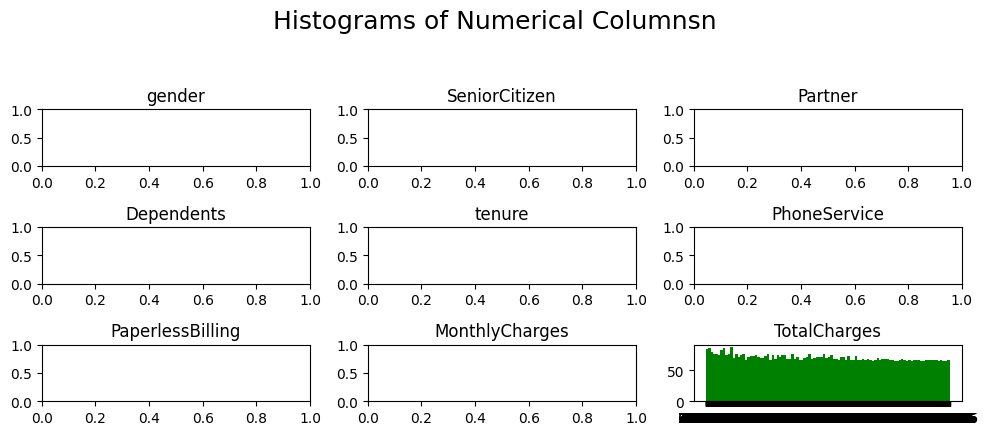

In [17]:
dataset_1 = dataset[['gender',
'SeniorCitizen', 'Partner','Dependents',
'tenure', 'PhoneService', 'PaperlessBilling',
'MonthlyCharges', 'TotalCharges']]

fig = plt.figure(figsize=(10, 8))
plt.suptitle('Histograms of Numerical Columnsn',horizontalalignment="center",fontstyle = "normal", fontsize = 18, fontfamily = "sans-serif")
for i in range(dataset_1.shape[1]):
    plt.subplot(6, 3, i + 1)
    f = plt.gca()
    f.set_title(dataset_1.columns.values[i])
vals = np.size(dataset_1.iloc[:, i].unique())
if vals >= 100:
    vals = 100

plt.hist(dataset_1.iloc[:, i], bins=vals, color = 'green')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

**Analyze the distribution of categorical variables**

Most of the customers seem to have a prepaid connection with the telecom company. On the other hand, there are a more or less equal proportion of customers in the 1-year and 2-year contracts.

AttributeError: 'Annotation' object has no property 'vrt'

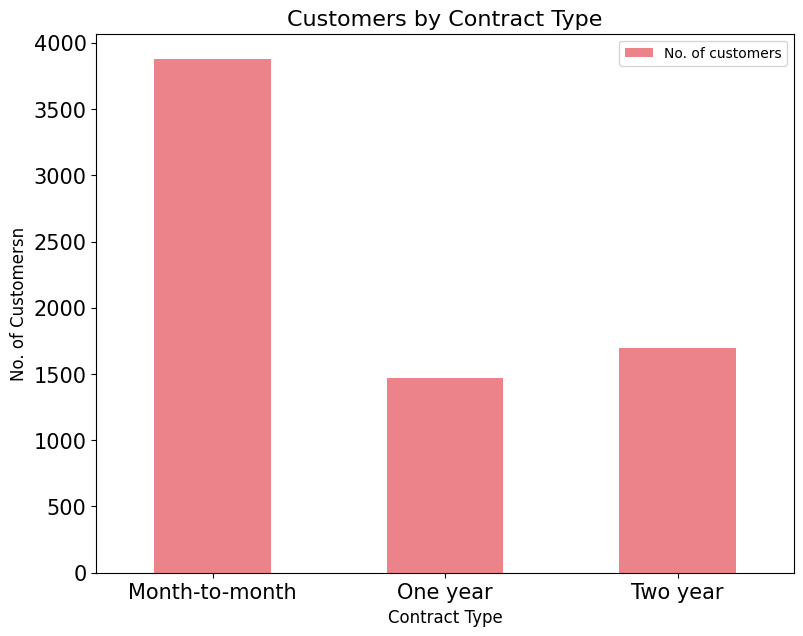

In [18]:
contract_split = dataset[[ "customerID", "Contract"]]
sectors = contract_split .groupby ("Contract")
contract_split = pd.DataFrame(sectors["customerID"].count())
contract_split.rename(columns={'customerID':'No. of customers'}, inplace=True)

ax =  contract_split[["No. of customers"]].plot.bar(title = 'Customers by Contract Type',legend =True, table = False,
grid = False,  subplots = False,figsize =(9, 7), color ='#ec838a',
fontsize = 15, stacked=False)
plt.ylabel('No. of Customersn',
horizontalalignment="center",fontstyle = "normal",
fontsize = "large", fontfamily = "sans-serif")
plt.xlabel('Contract Type',
horizontalalignment="center",fontstyle = "normal",
fontsize = "large", fontfamily = "sans-serif")
plt.title('Customers by Contract Type',
horizontalalignment="center",fontstyle = "normal",
fontsize = "16", fontfamily = "sans-serif")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
x_labels = np.array(contract_split[["No. of customers"]])


def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        vrt = 'bottom'
        if y_value < 0:
            space *= -1
            vrt = 'top'
        label = "{:.0f}".format(y_value)

    ax.annotate(label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            vrt=vrt)

add_value_labels(ax)

**Payment Method Distribution**

Customers pay their bills electronically, mostly by bank transfer, credit card and mailed checks.

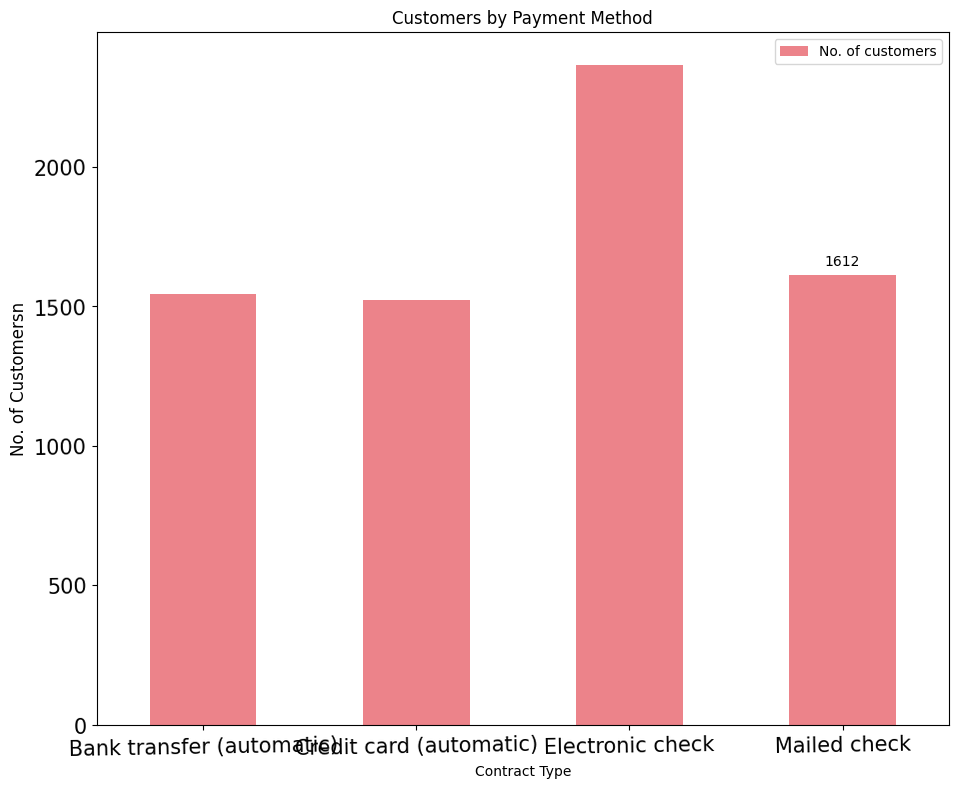

In [19]:
payment_method_split = dataset[[ "customerID", "PaymentMethod"]]
sectors = payment_method_split  .groupby ("PaymentMethod")
payment_method_split  = pd.DataFrame(sectors["customerID"].count())
payment_method_split.rename(columns={'customerID':'No. of customers'}, inplace=True)
ax =  payment_method_split [["No. of customers"]].plot.bar(title = 'Customers by Payment Method', legend =True, table = False, grid = False, subplots = False,  figsize =(11, 9),color ='#ec838a', fontsize = 15, stacked=False)
plt.ylabel('No. of Customersn',
horizontalalignment="center",fontstyle = "normal",
fontsize = "large", fontfamily = "sans-serif")
plt.xlabel('Contract Type',
horizontalalignment="center",fontstyle = "normal",
fontsize = "medium", fontfamily = "sans-serif")
plt.title('Customers by Payment Method',
horizontalalignment="center", fontstyle = "normal", fontsize = "12", fontfamily = "sans-serif")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=1, horizontalalignment="center")
plt.yticks(rotation=1, horizontalalignment="right")
x_labels = np.array(payment_method_split [["No. of customers"]])


def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)

    ax.annotate(label,
           (x_value, y_value),
            xytext=(0, space),textcoords="offset points",
            ha='center',va=va)
add_value_labels(ax)


**Analyze the churn rate by categorical variables**

/tmp/ipykernel_2644/619771681.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  churn_rate ["churn_label"] = pd.Series(


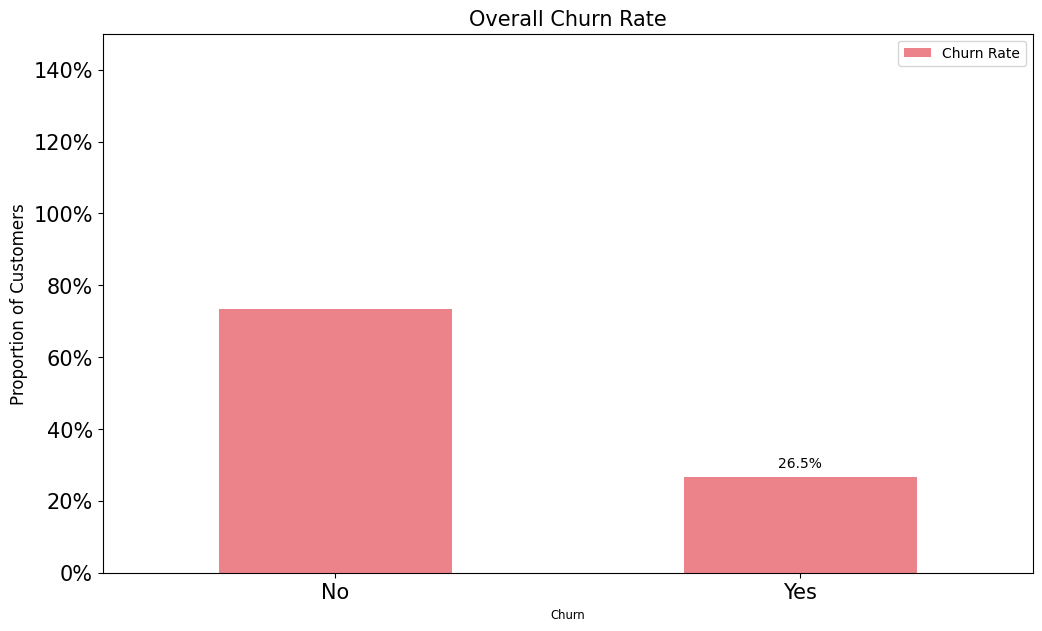

In [20]:
import matplotlib.ticker as mtick

churn_rate = dataset[["Churn", "customerID"]]
churn_rate ["churn_label"] = pd.Series(
np.where((churn_rate["Churn"] == 0), "No", "Yes"))
sectors = churn_rate .groupby ("churn_label")
churn_rate = pd.DataFrame(sectors["customerID"].count())

churn_rate ["Churn Rate"] = (
churn_rate ["customerID"]/ sum(churn_rate ["customerID"]) )*100

ax =  churn_rate[["Churn Rate"]].plot.bar(title = 'Overall Churn Rate',legend =True, table = False,grid = False,  subplots = False,
figsize =(12, 7), color = '#ec838a', fontsize = 15, stacked=False,
ylim =(0,150))
plt.ylabel('Proportion of Customers',horizontalalignment="center",
fontstyle = "normal", fontsize = "large", fontfamily = "sans-serif")
plt.xlabel('Churn',horizontalalignment="center",fontstyle = "normal", fontsize = "small", fontfamily = "sans-serif")
plt.title('Overall Churn Rate',horizontalalignment="center",
fontstyle = "normal", fontsize = "15", fontfamily = "sans-serif")
plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
x_labels = np.array(churn_rate[["customerID"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
    label = "{:.1f}%".format(y_value)

    ax.annotate(label,
                (x_value, y_value),
                 xytext=(0, space),
                 textcoords="offset points",
                 ha='center',va=va)
add_value_labels(ax)
ax.autoscale(enable=False, axis='both', tight=False)

Overall churn rate shows that around 100% of the customers are active. As shown in the chart above, this is an balanced classification problem. Machine learning algorithms work well when the number of instances of each class is roughly equal. Since the dataset is skewed, we need to keep that in mind while choosing the metrics for model selection.

**Churn Rate by Contract Type**

Customers with a prepaid or rather a month-to-month connection have a very high probability to churn compared to their peers on 1 or 2 years contracts.

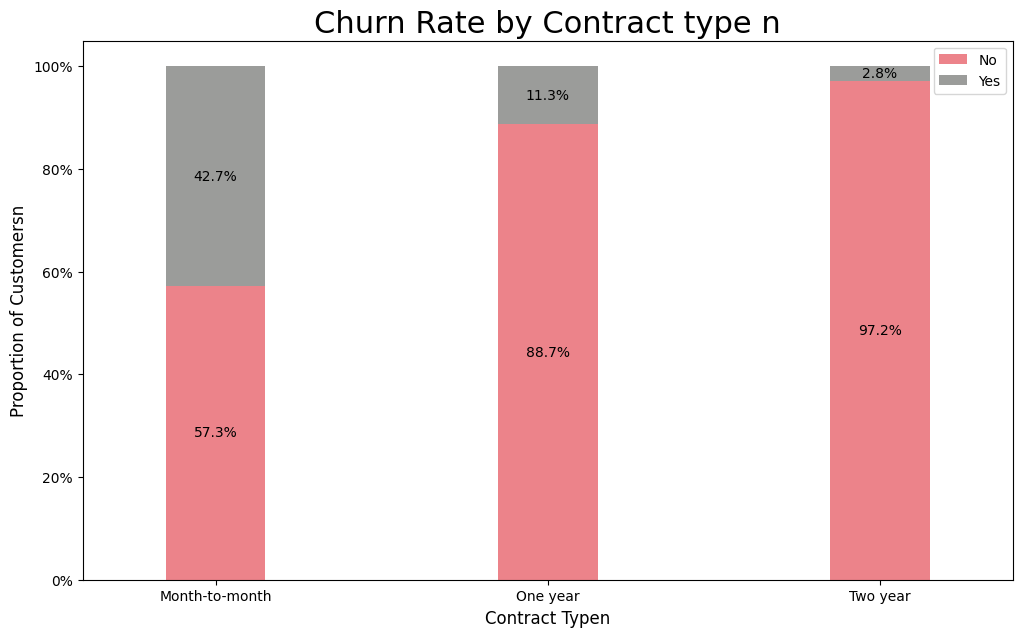

In [21]:
import matplotlib.ticker as mtick


contract_churn = dataset.groupby(
['Contract','Churn']).size().unstack()
contract_churn.rename(
columns={0:'No', 1:'Yes'}, inplace=True)
colors  = ['#ec838a','#9b9c9a']


ax = (contract_churn.T*100.0 / contract_churn.T.sum()).T.plot(kind='bar',width = 0.3,stacked = True,rot = 0,figsize = (12,7),color = colors)

plt.ylabel('Proportion of Customersn',
horizontalalignment="center",fontstyle = "normal",
fontsize = "large", fontfamily = "sans-serif")

plt.xlabel('Contract Typen',horizontalalignment="center",
fontstyle = "normal", fontsize = "large",
fontfamily = "sans-serif")

plt.title('Churn Rate by Contract type n',
horizontalalignment="center", fontstyle = "normal",
fontsize = "22", fontfamily = "sans-serif")

plt.legend(loc='upper right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x+width/2,
            y+height/2,
            '{:.1f}%'.format(height),
            horizontalalignment='center',
            verticalalignment='center')
ax.autoscale(enable=False, axis='both', tight=False)

**Plot Correlation Matrix of all independent variables**

<Axes: >

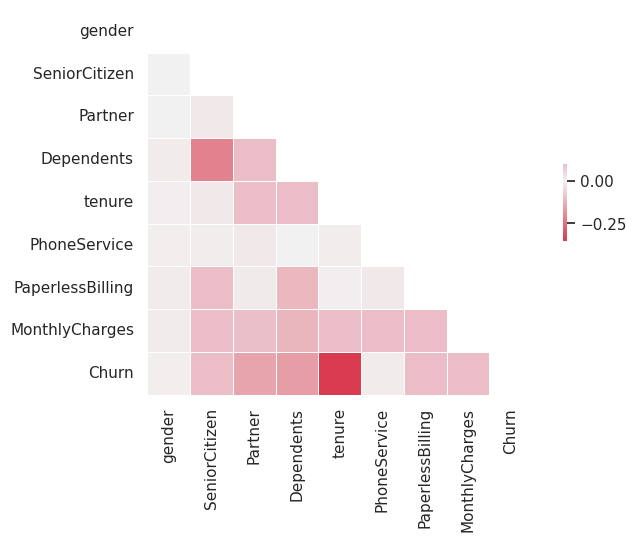

In [22]:
sn.set(style="white")
corr = dataset.select_dtypes(include=[np.number]).corr()

#Generate a mask for the upper triangle:
mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

#Set up the matplotlib figure and a diverging colormap:
f, ax = plt.subplots(figsize=(8, 5))
cmap = sn.diverging_palette(8, 4, as_cmap=True)

#Draw the heatmap with the mask and correct aspect ratio:
sn.heatmap(corr, mask=mask, cmap=cmap, vmax=.1, center=0,
square=True, linewidths=.5, cbar_kws={"shrink": .2})

# **Exploratory Data Analysis**

Let us summarise some of the key findings from this Exploratory Data Analysis:-

* The dataset does not have any missing or erroneous data values.
* The dataset has the majority of customers being active.
* Most of the customers in the dataset are younger people.
* Most of the customers seem to have phone service with Monthly charges spanning between Rs18 to Rs118 per customer.
* Customers with a month-to-month connection have a very high probability to churn that too if they have subscribed to pay via electronic checks.

#Encode Categorical data

Any categorical variable that has more than two unique values have been dealt with Label Encoding and one-hot Encoding using get_dummies method in pandas.

In [23]:
#Incase if user_id is an object:

identity = dataset["customerID"]
dataset = dataset.drop(columns="customerID")

#Convert rest of categorical variable into dummy:
dataset= pd.get_dummies(dataset)

#Rejoin userid to dataset:
dataset = pd.concat([dataset, identity], axis = 1)

# Split the dataset into dependent and independent variables

Now we need to separate the dataset into X and y values. y would be the ‘Churn’ column while X would be the remaining list of independent variables in the dataset.

In [24]:
#Identify response variable:

response = dataset["Churn"]
dataset = dataset.drop(columns="Churn")

#Since "Churn" is already droped from the dataset, hence it throws error.

#Generate training and test datasets

Let’s divide the master dataset into training and test set with an 80%-20% ratio.

In [25]:
X = dataset['MonthlyCharges']
y = dataset['tenure']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)


Training set size: 5634
Test set size: 1409
Number transactions X_train dataset:  (5634,)
Number transactions y_train dataset:  (5634,)
Number transactions X_test dataset:  (1409,)
Number transactions y_test dataset:  (1409,)


#Conduct Feature Scaling

It is important to normalize the variables before conducting any machine learning algorithms so that all the training and test variables are scaled within a range of 0 to 1.

In [26]:
from sklearn.preprocessing import MinMaxScaler

X = dataset['MonthlyCharges']
y = dataset['tenure']

# 3. Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize the MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 5. Fit on Training data and Transform both
# We "fit" only on training data to learn the Min and Max values
X_train_scaled = scaler.fit_transform(X_train)
y_train_scaled = scaler.fit_transform(y_train)

# We "transform" the test data using the Min/Max learned from training
X_test_scaled = scaler.transform(X_test)
y_test_scaled = scaler.transform(y_test)

# Convert back to DataFrame for easy viewing
X_train_scaled_ddataset = pd.dataset(X_train_scaled, columns=X.columns)
y_train_scaled_ddataset = pd.dataset(y_train_scaled, columns=y.columns)

print("Scaled Training Data:")
print(X_train_scaled_ddataset)
print(y_train_scaled_ddataset)

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

# **Model  Selection**

Let's model classification algorithm over the training dataset and evaluate their accuracy and standard deviation scores.
Classification Accuracy is one of the most common classification evaluation metrics to compare baseline algorithms as its the number of correct predictions made as a ratio of total predictions. However, it’s not the ideal metric when we have class imbalance issue. Hence, let us sort the results based on the ‘Mean AUC’ value.

In [37]:
models = []
models.append(('Logistic Regression', LogisticRegression(solver='liblinear', random_state = 0,
                                                         class_weight='balanced')))
models.append(('SVC', SVC(kernel = 'linear', random_state = 0)))
models.append(('Kernel SVM', SVC(kernel = 'rbf', random_state = 0)))
models.append(('KNN', KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)))
models.append(('Gaussian NB', GaussianNB()))
models.append(('Decision Tree Classifier',
               DecisionTreeClassifier(criterion = 'entropy', random_state = 0)))
models.append(('Random Forest', RandomForestClassifier(
    n_estimators=100, criterion = 'entropy', random_state = 0)))
#Evaluating Model Results:
acc_results = []
auc_results = []
names = []
# set table to table to populate with performance results
col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD',
       'Accuracy Mean', 'Accuracy STD']
model_results = pd.DataFrame(columns=col)
i = 0
# Evaluate each model using k-fold cross-validation:
for name, model in models:
    kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=0)

# accuracy scoring:
    cv_acc_results = model_selection.cross_val_score(
    model, X_train, y_train, cv=kfold, scoring='accuracy')
# roc_auc scoring:
    cv_auc_results = model_selection.cross_val_score(
    model, X_train, y_train, cv=kfold, scoring='roc_auc')
    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    model_results.loc[i] = [name,
                         round(cv_auc_results.mean()*100, 2),
                         round(cv_auc_results.std()*100, 2),
                         round(cv_acc_results.mean()*100, 2),
                         round(cv_acc_results.std()*100, 2)
                         ]
    i += 1
model_results.sort_values(by=['ROC AUC Mean'], ascending=False)

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1222, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py", line 2961, in validate_data
    X, y = check_X_y(X, y, **che